In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from paicos.util import get_index_of_radial_range as RadialRange
import os

pa.settings.strict_units = False

snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
R200 = snap.Cat.Group['Group_R_Crit200'][0]
widths = 2.0 * np.ones(3) * R200


filter_weight = None
filter_type = 'gaussian'
conversion_factor = 5.33645 ## between physical length scale and filter size (Eq.A6 of Perrone+2026)
physical_scale = 60 ## this is in kpc physical units!

kpc = pa.units.PaicosQuantity(1 * snap.h /snap.a, 'kpc small_a / small_h ', 
                              h=snap.h, a=snap.a, comoving_sim=True)

filter_length = physical_scale*kpc.to('arepo_length')/conversion_factor

idxR200 = RadialRange(snap["0_Coordinates"],
                          center, 0*R200, R200)


In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm, Normalize, SymLogNorm
from matplotlib.patches import Circle, Rectangle
import matplotlib.patches as patches
from matplotlib.ticker import LogLocator, LogFormatter
from matplotlib.gridspec import GridSpec

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

colors20b = plt.get_cmap('tab20b').colors
colors20c = plt.get_cmap('tab20c').colors

rdpu = plt.cm.RdPu(np.linspace(0,1,4))
pubu = plt.cm.PuBu(np.linspace(0,1,4))

plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 12
plt.rcParams['ytick.labelsize']= 12
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'

In [3]:
sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                                    search_radius=filter_length)

turb = {}

Attempting to get derived variable: 0_Volume...	[DONE]



In [4]:
turb['smooth_rho'], _ = tc.extract_turbulent_scalar(snap, sf, '0_Density', 
                                                   filter_length, 
                                                   weight=filter_weight, 
                                                   filter_type=filter_type, 
                                                   iterative=False, optimized=True, 
                                                   selection=idxR200)

min/max/avg occupancy cartesian tiling 0 / 847 / 2.38


In [5]:
# gradient_rho_smooth = sf.derivative_variable(snap['0_Density'], filter_length, 
#                                              weight=None, filter_type=filter_type, 
#                             iterative=False, optimized=True, selection=idxR200)

In [6]:
turb['gradient_rho_smooth'] = tc.extract_derivative_scalar(snap, sf, '0_Density', 
                                                   filter_length, filter_type="gaussian", 
                                                 selection=idxR200)

min/max/avg occupancy cartesian tiling 0 / 847 / 2.38


In [7]:
analysisfolder = '/llust21/cosmo-plasm/lperrone/turbocluster-analysis/derivative_test/'

if not os.path.exists(analysisfolder):
        os.makedirs(analysisfolder)
    
writer = pa.PaicosWriter(snap, basedir=analysisfolder, 
                            basename='smooth_rho_mult_10')

for key in turb.keys():
    writer.write_data(key, turb[key])

writer.finalize()

In [8]:
widths_slicer = 2.0 * np.ones(3) * R200
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=1024)

extent = slicer.centered_extent.to('Mpc').to_physical

In [9]:
dens_smooth = slicer.slice_variable(turb['smooth_rho']).to_physical.cgs

In [10]:
grad_x_logrho = slicer.slice_variable(turb['gradient_rho_smooth'][:,0]/turb['smooth_rho']).to_physical.to('1 / kpc')
grad_y_logrho = slicer.slice_variable(turb['gradient_rho_smooth'][:,1]/turb['smooth_rho']).to_physical.to('1 / kpc')
grad_z_logrho = slicer.slice_variable(turb['gradient_rho_smooth'][:,2]/turb['smooth_rho']).to_physical.to('1 / kpc')
grad_logrho = [grad_x_logrho, grad_y_logrho, grad_z_logrho]

/lustre/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


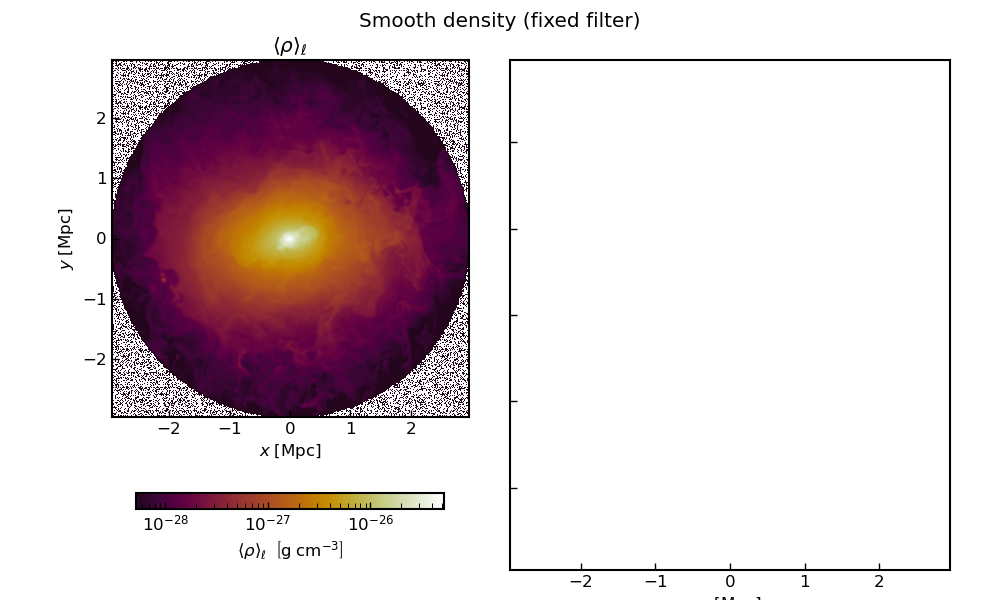

In [11]:

vmax = dens_smooth.value.max()
vmin = 1e-3*vmax
norm = LogNorm(vmin=vmin,vmax=vmax)

cmap = cmr.fall
# cmap2 = cmr.rainforest
# cmap2 = cmr.prinsenvlag_r
# cmap2 = cmr.eclipse
# cmap2 = cmr.ghostlight

fig, axes = plt.subplots(1,2, figsize=(10,6),sharex=True, sharey=True)

im00 = axes[0].imshow(
    dens_smooth.value, origin='lower', cmap=cmap, norm=norm, extent=extent.value)
# im01 = axes[0,1].imshow(
#     MAG_EN_smoothed.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)




axes[0].set_title(r'$\langle \rho \rangle_\ell$')
# axes[1].set_title(r'$\langle e_B \rangle_l$')

for i in range(2):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))
# axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.7)
cbar00.set_label(dens_smooth.label('\\langle \\rho \\rangle_\\ell'))

# cbar01 = fig.colorbar(im01, orientation='horizontal',shrink=0.7)
# cbar01.set_label(MAG_EN_smoothed.label('1/8\\pi \\langle B^2 \\rangle_l'))

# cbar10 = fig.colorbar(im10, orientation='horizontal',shrink=0.7)
# cbar10.set_label(MAG_EN_e_m.label('e_m'))

# cbar11 = fig.colorbar(im11, orientation='horizontal',shrink=0.7)
# cbar11.set_label(MAG_EN_e_b.label('e_{b}'))

fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle('Smooth density (fixed filter)',y=0.98)
plt.savefig('./smooth_density.pdf', dpi=400)

plt.show()

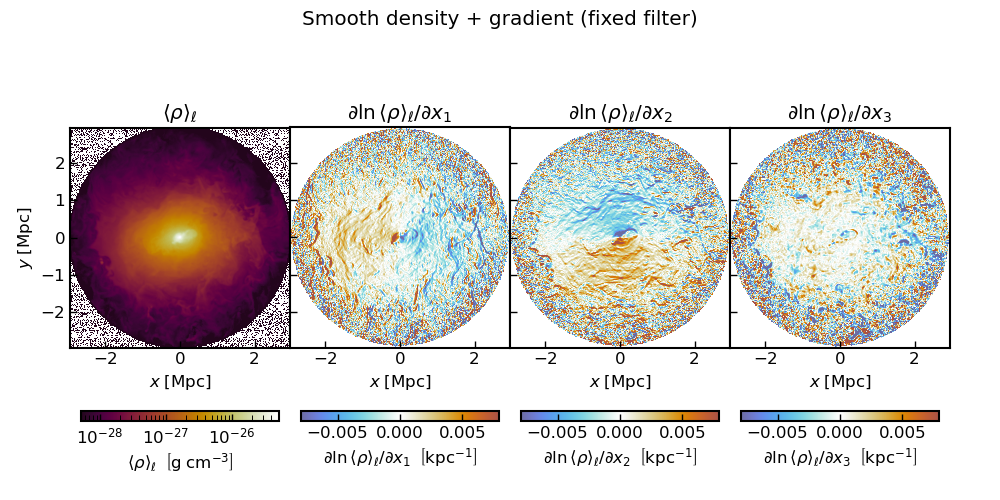

In [12]:

vmax = dens_smooth.value.max()
vmin = 1e-3*vmax
norm = LogNorm(vmin=vmin,vmax=vmax)

vmax = 1e-1*np.nanmax(grad_logrho)
vmin = -vmax
norm2 = Normalize(vmin=vmin,vmax=vmax)
# norm2 = SymLogNorm(linthresh=3e-3*vmax, linscale=3.0,
#                         vmin=-8e-1*vmax, vmax=8e-1*vmax, base=10)

cmap = cmr.fall
# cmap2 = cmr.rainforest
cmap2 = cmr.prinsenvlag_r
# cmap2 = cmr.eclipse
# cmap2 = cmr.ghostlight

fig, axes = plt.subplots(1,4, figsize=(10,5),sharex=True, sharey=True)

im00 = axes[0].imshow(
    dens_smooth.value, origin='lower', cmap=cmap, norm=norm, extent=extent.value)

ims_grad = []
for i in range(3):
    imgrad = axes[i+1].imshow(
    grad_logrho[i].value, origin='lower', cmap=cmap2, norm=norm2, extent=extent.value)

    ims_grad.append(imgrad)
    axes[i+1].set_title(r'$\partial \ln \langle \rho \rangle_\ell / \partial x_%s$'%(i+1))


axes[0].set_title(r'$\langle \rho \rangle_\ell$')



for i in range(4):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))
# axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.9)
cbar00.set_label(dens_smooth.label('\\langle \\rho \\rangle_\\ell'))

for i in range(3):
    cbar = fig.colorbar(ims_grad[i], orientation='horizontal',shrink=0.9)
    cbar.set_label(grad_logrho[i].label('\\partial \\ln \\langle \\rho \\rangle_\\ell / \\partial x_%s'%(i+1)))


fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle('Smooth density + gradient (fixed filter)',y=0.98)
plt.savefig('./gradient_smooth_density_mult_10.pdf', dpi=400)

# plt.show()

In [13]:
turb_mult_4 = pa.PaicosReader(analysisfolder, 305,
                        basename='smooth_rho_mult_4')

turb_mult_6 = pa.PaicosReader(analysisfolder, 305,
                        basename='smooth_rho_mult_6')

turb_mult_10 = pa.PaicosReader(analysisfolder, 305,
                        basename='smooth_rho_mult_10')

In [ ]:
turb_mult_4['gradient_rho_smooth'].shape

In [ ]:
rel_diff = np.abs(turb_mult_4['smooth_rho'][idxR200] - 
                  turb_mult_6['smooth_rho'][idxR200])/turb_mult_4['smooth_rho'][idxR200]

In [ ]:
rel_diff

In [ ]:
fig, ax = plt.subplots()

ax.hist(rel_diff, bins=500, range=(1e-4,1e-1), density=False, 
        weights=None, cumulative=False, bottom=None, histtype='bar', 
        align='mid', orientation='vertical', log=True)

ax.set_title(r'Histogram relative difference $\langle \rho \rangle_\ell$')


ax.set_xlabel('$\epsilon$')

ax.set_ylabel('count')


fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

In [ ]:
np.abs(turb_mult_4['gradient_rho_smooth'][:,0][idxR200] - 
                  turb_mult_6['gradient_rho_smooth'][:,0][idxR200])

In [ ]:
turb_mult_4['gradient_rho_smooth'][:,0][idxR200]

In [ ]:
turb_mult_6['gradient_rho_smooth'][:,0][idxR200]

In [ ]:
# rel_diff_gradx = filter_length*np.abs(turb_mult_4['gradient_rho_smooth'][:,0][idxR200] - 
#                   turb_mult_6['gradient_rho_smooth'][:,0][idxR200])/turb_mult_4['smooth_rho'][idxR200]

In [ ]:
np.abs(turb_mult_4['gradient_rho_smooth'][:,0][idxR200] + 
                  turb_mult_6['gradient_rho_smooth'][:,0][idxR200])

In [ ]:
np.abs(turb_mult_4['gradient_rho_smooth'][:,0][idxR200] - 
                  turb_mult_6['gradient_rho_smooth'][:,0][idxR200])

In [14]:
# rel_diff_gradx = np.abs(turb_mult_4['gradient_rho_smooth'][:,0] - 
#                   turb_mult_6['gradient_rho_smooth'][:,0]) / \
#                     np.abs(turb_mult_4['gradient_rho_smooth'][:,0] + 
#                   turb_mult_6['gradient_rho_smooth'][:,0])

rel_diff_gradx = np.abs(turb_mult_6['gradient_rho_smooth'][:,0] - 
                  turb_mult_10['gradient_rho_smooth'][:,0]) / \
                    np.abs(turb_mult_6['gradient_rho_smooth'][:,0] + 
                  turb_mult_10['gradient_rho_smooth'][:,0])

/lustre/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [ ]:
# turb_mult_4['gradient_rho_smooth'][210,0], turb_mult_6['gradient_rho_smooth'][210,0]

In [ ]:
# np.abs(turb_mult_4['gradient_rho_smooth'][210,0] - 
#                   turb_mult_6['gradient_rho_smooth'][210,0])

In [ ]:
# np.abs(turb_mult_4['gradient_rho_smooth'][210,0] + 
#                   turb_mult_6['gradient_rho_smooth'][210,0])

In [ ]:
# rel_diff_gradx[210]

In [ ]:
# np.argwhere(rel_diff_gradx>10)

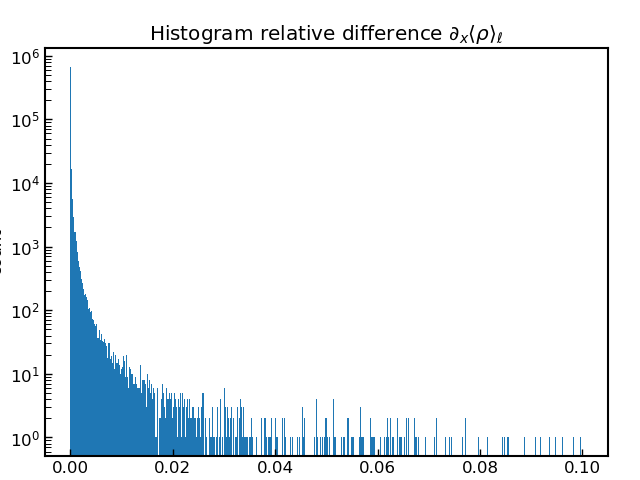

In [19]:
fig, ax = plt.subplots()

ax.hist(rel_diff_gradx[idxR200], bins=500, range=(1e-5, 1e-1), density=False, 
        weights=None, cumulative=False, bottom=None, histtype='bar', 
        align='mid', orientation='vertical', log=True)

ax.set_title(r'Histogram relative difference $\partial_x \langle \rho \rangle_\ell$')


ax.set_xlabel('$\epsilon$')

ax.set_ylabel('count')


fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

plt.savefig('./comparison_hist_gradient_x_mult_6_10.pdf', dpi=400)

In [ ]:
rel_diff_gradx_sliced = slicer.slice_variable(rel_diff_gradx).to_physical


# vmax = np.nanmax(rel_diff_gradx_sliced)
vmax = 1.0
vmin = 1e-3*vmax
norm = LogNorm(vmin=vmin,vmax=vmax)

cmap = cmr.fall


fig, axes = plt.subplots(1,3, figsize=(10,5),sharex=True, sharey=True)

im00 = axes[0].imshow(
    rel_diff_gradx_sliced .value, origin='lower', cmap=cmap, norm=norm, extent=extent.value)
# im01 = axes[0,1].imshow(
#     MAG_EN_smoothed.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)


axes[0].set_title(r'$\partial_x$')
# axes[1].set_title(r'$\langle e_B \rangle_l$')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))
# axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.7)
cbar00.set_label(r'$\epsilon$')


fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle(r'relative difference $\partial_i \langle \rho \rangle_\ell$')

plt.show()